# **Algerian Forest Fires Dataset**

Data set information

The dataset includes 244 instances that regroup a data of two regions of Algeria namely the Bejaia region located in the northeast of Algeria and the sidi Bel-abbes region located in the northwest of Algeria

122 instances for each region

The period from june 2012 to september 2012 The dataset includes 11 attributes and 1 output attritude class The 244 instances have been classified into fire 138 classes and not fire 106 classes


Attribute information:

1. Date : (DD/MM/YYYY) Day month (june to september) year 2012 wealther data observations

2. Temp : Temperature noon temperature max in celsius degrees 22 to 42

3. RH : Relative Humidity in % 21 to 90

4. WS : Wind speed in km/h:6 to 29

5. Rain : Total day in mm 0 to 16.8 FWI components

6. Fine Fuel Moisture code (FFMC) index from FWI system : 28.6 to 92.5

7. Duff Moisture code (DMC) index from FWI system 1.1 to 65.9

8. Drought code (DC) index from the FWI system 7 to 220.4

9. initial spread index (ISI) index from the FWI system 0 to 18.5

10. Buildup index (BUI) index from the FWI system : 1.1 to 68

11. Fire Weather index (FWI) index 0 to 31.1

12. classes two classes namely fire and not fire

1. Read the Dataset
2. EDA , FE
3. Divide the dataset into independent & dependent feature
4. Further devide the dataset into the train & test
5. standard scaling on the train & test data
6. training the model

# Step : 1. Read The Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('Algerian_forest_fires_dataset_UPDATE.xlsx',header=1)
df.head(2)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire


In [4]:
df.shape

(247, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4   RH           245 non-null    object
 5   Ws           245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


# Data cleaning

In [6]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
RH             2
Ws             2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

In [7]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


# Adding New column region

In [8]:
df.loc[:122,'region'] = 0
df.loc[122:,'region'] = 1

In [9]:
df[['region']] = df[['region']].astype(int)

In [10]:
df.head(2)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0


In [11]:
df.tail(2)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
245,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1
246,30,9,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4   RH           245 non-null    object
 5   Ws           245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
 14  region       247 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 29.1+ KB


In [13]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
RH             2
Ws             2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
region         0
dtype: int64

# removing the null values

In [14]:
df = df.dropna().reset_index(drop=True)

In [15]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
region         0
dtype: int64

In [16]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [17]:
df = df.drop(122).reset_index(drop=True)

In [18]:
df.shape

(243, 15)

In [19]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region'],
      dtype='object')

# strip function removing space form the column name

In [20]:
df.columns = df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        243 non-null    object
 2   year         243 non-null    object
 3   Temperature  243 non-null    object
 4   RH           243 non-null    object
 5   Ws           243 non-null    object
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  region       243 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 28.6+ KB


In [22]:
df.head(2)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0


#  change the object type data into int type data and Float type data

In [23]:
df[['day','month','year','Temperature','RH','Ws']] = df[['day','month','year','Temperature','RH','Ws']].astype(int)
df[['Rain','FFMC','DMC','DC','ISI','BUI','FWI']] = df[['Rain','FFMC','DMC','DC','ISI','BUI','FWI']].astype(float)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [25]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


# EDA

# delete columns name day month year

In [26]:
df = df.drop(['day','month','year'],axis=1)

In [28]:
df.head(2)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0


In [29]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

# fire = 1
# not fire = 0

In [30]:
df['Classes'] = df['Classes'].map({
    'not fire': 0,
    'fire': 1
})

In [31]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1


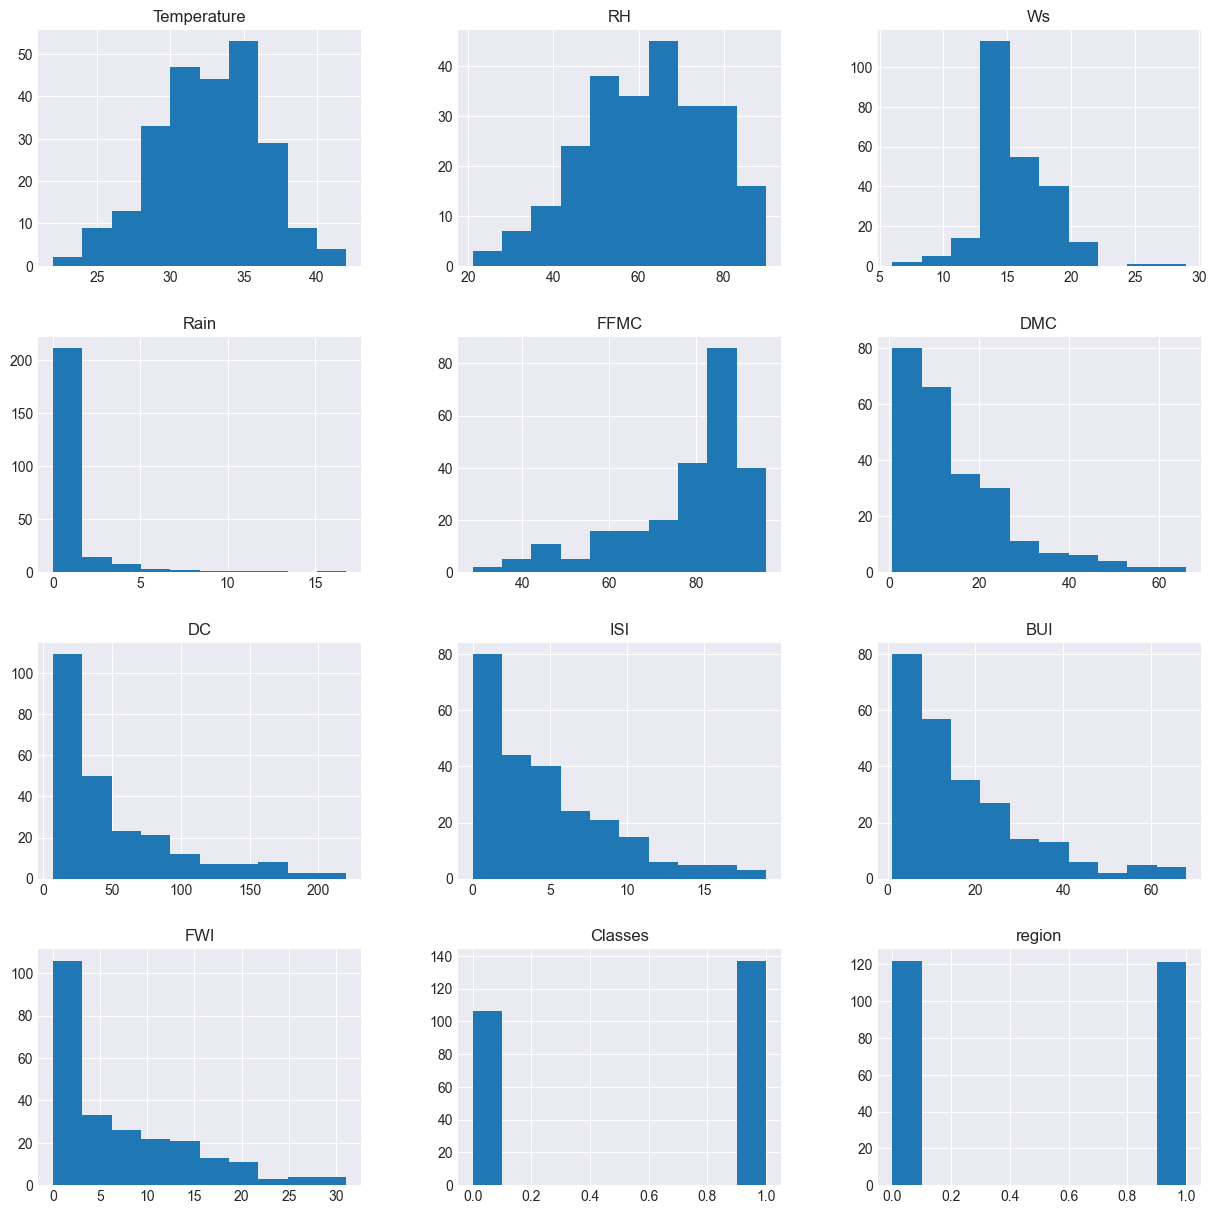

In [32]:
plt.style.use('seaborn-v0_8-darkgrid')
df.hist(figsize=(15,15))
plt.show()

# corrrelation

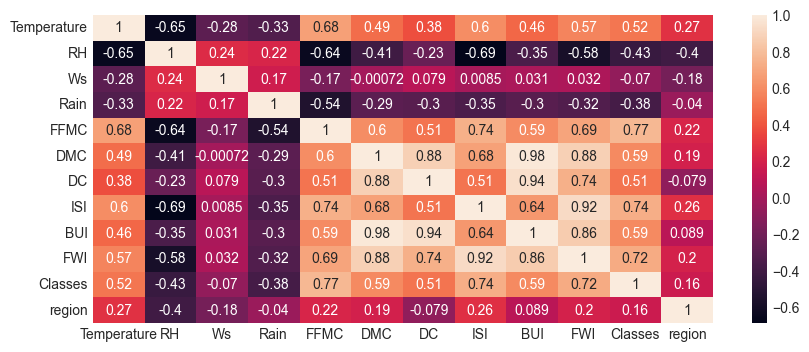

In [33]:
plt.figure(figsize=(10,4))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  243 non-null    int64  
 1   RH           243 non-null    int64  
 2   Ws           243 non-null    int64  
 3   Rain         243 non-null    float64
 4   FFMC         243 non-null    float64
 5   DMC          243 non-null    float64
 6   DC           243 non-null    float64
 7   ISI          243 non-null    float64
 8   BUI          243 non-null    float64
 9   FWI          243 non-null    float64
 10  Classes      243 non-null    int64  
 11  region       243 non-null    int64  
dtypes: float64(7), int64(5)
memory usage: 22.9 KB


# 1. input feature =  Temperature	RH	Ws	Rain	FFMC	DMC	DC	ISI	BUI	Classes	region
# 2. output feature = FWI

# 3 Divide the dataset into independent & dependent feature

# 1. x = independent feature
# 2. y = dependent feature

In [35]:
x = df.drop('FWI',axis=1)
y = df['FWI']

In [36]:
x.head(2)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0


In [37]:
y.head(2)

0    0.5
1    0.4
Name: FWI, dtype: float64

# 4 Further devide the dataset into the train & test

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.25, random_state=10)

In [39]:
x_train.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
149,37,37,13,0.0,92.5,27.2,52.4,11.7,27.1,1,1
208,36,54,14,0.0,91.0,65.9,177.3,10.0,68.0,1,1
103,29,88,13,0.0,71.0,2.6,16.6,1.2,3.7,0,0


In [40]:
print("The x train shape : ",x_train.shape)
print("The x test shape  : ",x_test.shape)
print("The y train shape : ",y_train.shape)
print("The y test shape  : ",y_test.shape)

The x train shape :  (182, 11)
The x test shape  :  (61, 11)
The y train shape :  (182,)
The y test shape  :  (61,)


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  243 non-null    int64  
 1   RH           243 non-null    int64  
 2   Ws           243 non-null    int64  
 3   Rain         243 non-null    float64
 4   FFMC         243 non-null    float64
 5   DMC          243 non-null    float64
 6   DC           243 non-null    float64
 7   ISI          243 non-null    float64
 8   BUI          243 non-null    float64
 9   FWI          243 non-null    float64
 10  Classes      243 non-null    int64  
 11  region       243 non-null    int64  
dtypes: float64(7), int64(5)
memory usage: 22.9 KB


# Multiple corelation andf co-linear Feature

In [42]:
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,region
Temperature,1.000000,-0.669720,-0.334140,-0.353265,0.677623,0.487571,0.389471,0.602026,0.467013,0.546279,0.283242
RH,-0.669720,1.000000,0.204591,0.222707,-0.649486,-0.428679,-0.266198,-0.707446,-0.383706,-0.463607,-0.401123
Ws,-0.334140,0.204591,1.000000,0.128902,-0.174288,-0.006788,0.058934,0.004938,0.020047,-0.098821,-0.181108
Rain,-0.353265,0.222707,0.128902,1.000000,-0.566291,-0.319280,-0.312623,-0.364699,-0.327179,-0.386251,-0.035181
FFMC,0.677623,-0.649486,-0.174288,-0.566291,1.000000,0.608838,0.520211,0.743021,0.600643,0.774048,0.248338
DMC,0.487571,-0.428679,-0.006788,-0.319280,0.608838,1.000000,0.885047,0.690427,0.983489,0.591989,0.193025
DC,0.389471,-0.266198,0.058934,-0.312623,0.520211,0.885047,1.000000,0.536126,0.944205,0.500287,-0.063488
ISI,0.602026,-0.707446,0.004938,-0.364699,0.743021,0.690427,0.536126,1.000000,0.664122,0.752023,0.280281
BUI,0.467013,-0.383706,0.020047,-0.327179,0.600643,0.983489,0.944205,0.664122,1.000000,0.589880,0.096093
Classes,0.546279,-0.463607,-0.098821,-0.386251,0.774048,0.591989,0.500287,0.752023,0.589880,1.000000,0.231666


# Multiple corelation function

In [43]:
def correlation(dataset,threshold):
    col_corr = set() # in set no duplicate value
    corr_matrix = dataset.corr() # correlation
    for i in range(len(corr_matrix.columns)): # check with each further
      for j in range(i):
        if abs(corr_matrix.iloc[i,j]) > threshold:
          colname = corr_matrix.columns[i]
          col_corr.add(colname)
    return col_corr



In [44]:
# calling the function
corr_features = correlation(x_train,0.85)
corr_features

{'BUI', 'DC'}

In [45]:
# delete the most common correlation feature from x_train & x_test

x_train.drop(corr_features,axis=1,inplace=True)
x_test.drop(corr_features,axis=1,inplace=True)

In [46]:
print("The x train shape is : ",x_train.shape)
print("The x test shape is  : ",x_test.shape)

The x train shape is :  (182, 9)
The x test shape is  :  (61, 9)


# 5 standard scaling on the train & test data

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [48]:
x_train_scaled

array([[-0.82246204, -0.13248758, -0.96126494, ..., -0.8800242 ,
        -1.0921406 , -1.        ],
       [-1.64946806,  1.26631775,  2.29867702, ..., -1.04641643,
        -1.0921406 , -1.        ],
       [ 1.38288736, -1.73112224, -0.96126494, ...,  1.66339986,
         0.91563303,  1.        ],
       ...,
       [ 0.28021266, -2.46382979, -0.96126494, ...,  2.25765782,
         0.91563303,  1.        ],
       [-0.54679336,  0.06734175, -0.59904916, ..., -0.59478038,
        -1.0921406 ,  1.        ],
       [-1.09813071,  1.06648841, -1.32348071, ..., -0.80871325,
        -1.0921406 , -1.        ]], shape=(182, 9))

In [49]:
x_test_scaled

array([[-8.22462036e-01,  4.67000417e-01, -5.99049163e-01,
        -4.08099905e-01,  3.82324752e-01, -4.03032864e-01,
        -3.57077199e-01,  9.15633026e-01, -1.00000000e+00],
       [-8.22462036e-01, -9.31804908e-01,  1.21202970e+00,
        -4.08099905e-01,  7.70459017e-01, -2.40355537e-01,
         1.04537158e+00,  9.15633026e-01,  1.00000000e+00],
       [ 1.10721869e+00, -4.65536466e-01,  1.25382383e-01,
        -4.08099905e-01,  7.90534928e-01,  7.12468805e-01,
         8.31438717e-01,  9.15633026e-01,  1.00000000e+00],
       [-1.64946806e+00,  1.19970797e+00,  1.93646125e+00,
         2.68665770e+00, -1.90632902e+00, -8.98811384e-01,
        -1.02264611e+00, -1.09214060e+00, -1.00000000e+00],
       [-8.22462036e-01,  1.13309819e+00, -5.99049163e-01,
         6.59057892e-01, -1.89963705e+00, -9.60783698e-01,
        -1.04641643e+00, -1.09214060e+00,  1.00000000e+00],
       [ 5.55881339e-01, -3.32316911e-01,  1.25382383e-01,
        -4.08099905e-01,  7.36999167e-01,  1.022330

In [50]:
x_train.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,region
1,29,61,13,1.3,64.4,4.1,1.0,0,0
2,26,82,22,13.1,47.1,2.5,0.3,0,0
149,37,37,13,0.0,92.5,27.2,11.7,1,1
208,36,54,14,0.0,91.0,65.9,10.0,1,1
103,29,88,13,0.0,71.0,2.6,1.2,0,0


# 6 Training the Model

# 1. Linear Regression Model

In [51]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.06,-0.22, 0.04,..., 4.63, 0.54,-0.42]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.023
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[28.8 ,14.84,13.48,..., 7.55, 5.86, 4.43]"


In [52]:
# predict
y_pred = lr.predict(x_test_scaled)
y_pred

array([ 4.34621195, 10.67373995, 12.9753663 ,  0.4135101 , -1.02488616,
       13.19946919,  3.20191627, 17.02853003,  6.68493498,  1.65329755,
        1.3394002 ,  7.23828016, 10.57153511, 11.26162371,  6.59652141,
       14.37784468,  0.16775376, 20.96435475,  6.07130094,  2.35717789,
        4.8009065 ,  1.79600584, 14.64159015,  1.16028556,  0.33934839,
        9.50375339,  1.69970775,  1.80949787,  0.89111593,  1.79404326,
        7.85801687,  5.14426939,  3.87443408,  8.34453306, 16.35964858,
        0.16473317,  1.322402  ,  0.5955332 , 13.91854575,  1.07036698,
       14.35427028, 10.41756323, 11.41865597,  7.73734617,  9.8352819 ,
       25.01125817,  0.65939849, 13.88789197, -0.22922468,  2.75122621,
        6.52145191, 22.97782455,  3.20799937,  8.26047586, -0.43174741,
       25.46846083, 11.89850511,  4.18616184,  0.2316082 ,  4.84985639,
       11.73074393])

In [53]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred) # accuracy for model

print("The mean absolute error      : ",mae)
print("The mean squared error       : ",mse)
print("The root mean squared error  : ",rmse)
print("R-square                     : ",r2)

The mean absolute error      :  0.6097576371929305
The mean squared error       :  0.7268326180583526
The root mean squared error  :  0.8525447894734638
R-square                     :  0.9845036003441805


# 2. Lasso Regression Model

In [54]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(x_train_scaled,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [55]:
# model test
y_pred = lasso.predict(x_test_scaled)
y_pred

array([ 4.40903932, 10.34980871, 12.42143752,  0.31472754,  0.03366997,
       12.53462945,  3.93443056, 15.72125148,  7.24172698,  2.57424406,
        3.26269706,  6.97799523, 10.14729144, 10.30019217,  6.61388214,
       12.8252594 ,  0.19883935, 19.14686136,  5.87884421,  1.84426329,
        4.58256845,  3.03301062, 13.04058726,  3.01359487,  1.37713699,
        9.59144612,  2.96074013,  3.45833819,  2.15161274,  2.5993233 ,
        7.48037949,  5.81075359,  4.40903932,  7.84894342, 14.38850512,
        0.87057286,  2.97118981,  2.3660633 , 12.50179678,  2.21612981,
       13.57553321, 10.12848201, 10.45612451,  7.6048984 ,  9.09802793,
       22.47532812,  2.38965893, 12.50537034,  1.76781293,  3.12381956,
        6.33821709, 20.87709542,  3.46730426,  7.82595412, -0.36536572,
       22.60193696, 11.55257926,  5.58821426,  2.0440843 ,  4.7241422 ,
       10.70610399])

In [56]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred) # accuracy for model

print("The mean absolute error      : ",mae)
print("The mean squared error       : ",mse)
print("The root mean squared error  : ",rmse)
print("R-square                     : ",r2)

The mean absolute error      :  1.1914563426451286
The mean squared error       :  2.3089600959649785
The root mean squared error  :  1.5195262735355972
R-square                     :  0.9507719280238188


# 3. Ridge Regression Model

In [57]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(x_train_scaled,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [58]:
y_pred = ridge.predict(x_test_scaled)
y_pred

array([ 4.38902715, 10.68518817, 12.97272743,  0.40409601, -1.0629079 ,
       13.20204776,  3.24433029, 17.00254123,  6.71625321,  1.70838684,
        1.36420161,  7.25809378, 10.62858843, 11.25191047,  6.70053677,
       14.36324446,  0.12449144, 20.8473788 ,  6.11098036,  2.36035216,
        4.89732912,  1.83340874, 14.63618913,  1.17318549,  0.35779863,
        9.52035641,  1.71855017,  1.85514035,  0.92290726,  1.77201167,
        7.87720498,  5.2008456 ,  3.99418901,  8.36068858, 16.37079985,
        0.14587179,  1.39203519,  0.64760432, 13.90254704,  1.13719108,
       14.34276351, 10.43456412, 11.41713804,  7.80012668,  9.856387  ,
       24.87012717,  0.71523685, 13.86705538, -0.18264348,  2.79236687,
        6.54580627, 22.85404525,  3.26533149,  8.26918985, -0.49160457,
       25.38519703, 11.89919864,  4.2123393 ,  0.20022956,  4.91681443,
       11.72006434])

In [59]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred) # accuracy for model

print("The mean absolute error      : ",mae)
print("The mean squared error       : ",mse)
print("The root mean squared error  : ",rmse)
print("R-square                     : ",r2)

The mean absolute error      :  0.6329143779561437
The mean squared error       :  0.7648721036898525
The root mean squared error  :  0.8745696677165591
R-square                     :  0.983692581331822


# 4. Elastic net regression

In [60]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet()
elastic.fit(x_train_scaled,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [61]:
y_pred = elastic.predict(x_test_scaled)
y_pred

array([ 5.82396345, 10.27053097, 12.10223255,  0.12768482,  0.05161994,
       12.20896368,  4.14350219, 14.7028492 ,  7.92199552,  3.53344367,
        3.89927172,  7.84512915, 11.03559894, 10.09868279,  8.32136022,
       12.27438249,  0.05721599, 16.76011879,  7.10600454,  1.49065084,
        6.47641188,  3.55782332, 12.53185563,  3.63989962,  1.70209711,
        9.85583685,  3.57088443,  3.6183658 ,  2.80831773,  3.15710569,
        8.43439995,  7.2466855 ,  6.85786587,  8.45163079, 13.37092323,
        0.88638068,  3.75806352,  3.0004756 , 11.94431915,  3.43177879,
       13.07506573, 10.51052786, 10.67680276,  9.35931479,  9.53018706,
       19.45052915,  3.15567491, 12.35305697,  2.07456895,  4.658037  ,
        7.29424925, 18.82415059,  5.24323461,  8.78363483, -0.55447175,
       20.08200463, 11.48042586,  5.65615564,  1.55272788,  6.39670675,
       10.50259845])

In [62]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred) # accuracy for model

print("The mean absolute error      : ",mae)
print("The mean squared error       : ",mse)
print("The root mean squared error  : ",rmse)
print("R-square                     : ",r2)

The mean absolute error      :  1.8874633328409456
The mean squared error       :  5.612237592790648
The root mean squared error  :  2.3690161655823814
R-square                     :  0.8803445600259008


# Pickle

In [63]:
import pickle
pickle.dump(scaler,open('scaler_model.pkl','wb'))
pickle.dump(ridge,open('ridge_model.pkl','wb'))
